In [72]:
import pandas as pd
import numpy as np
import pypsa
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Configuration

In [73]:
data_dir = Path("../data")
figure_dir = Path("../figures_paper")

mapping_pypsa_carriers = {
    "Combined-Cycle Gas": "Gas",
    "Load shedding": None,
    "Offshore Wind (AC)": "Wind Offshore",
    "Offshore Wind (DC)": "Wind Offshore",
    "Onshore Wind": "Wind Onshore",
    "Open-Cycle Gas": "Gas",
    "Run of River": "Run-of-river",
    "Solar": "Solar",
    "biomass": "Biomass",
    "nuclear": "Nuclear",
    "coal": "Coal",
    "lignite": "Lignite",
    "oil": "Oil",
    "solar-hsat": "Solar",
    "Pumped Hydro Storage": "Pumped Hydro Storage",
    "Reservoir & Dam": "Reservoir & Dam",
}

start_date = (pd.Timestamp("2022-01-01"),)
end_date = (pd.Timestamp("2022-12-31 23:00"),)


country = "ES"

resampling_rule = "W-MON"  # Weekly, starting on Monday

x_length = 6

phi = 1.618

data_dir = Path("../data")

n = pypsa.Network(data_dir / "network_files" / "hindcast-dyn-rolling-wy2022.nc")

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [74]:
# Color mapping for plotting

color_dict = n.carriers["color"].to_dict()

mapping_color = {
    "offwind-ac": "Wind Offshore",
    "offwind-dc": "Wind Offshore",
    "onwind": "Wind Onshore",
    "solar": "Solar",
    "solar-hsat": "Solar",
    "CCGT": "Gas",
    "OCGT": "Gas",
    "PHS": "Pumped Hydro Storage",
    "biomass": "Biomass",
    "coal": "Coal",
    "geothermal": "Geothermal",
    "hydro": "Reservoir & Dam",
    "lignite": "Lignite",
    "nuclear": "Nuclear",
    "oil": "Oil",
    "ror": "Run-of-river",
}

color_dict_new = {}

for original_name, new_name in mapping_color.items():
    # Use the color from the original carrier
    if original_name in color_dict:
        color_dict_new[new_name] = color_dict[original_name]


color_dict_new['Other'] = 'tab:red'
color_dict_new

{'Wind Offshore': '#74c6f2',
 'Wind Onshore': '#235ebc',
 'Solar': '#fdb915',
 'Gas': '#e0986c',
 'Pumped Hydro Storage': '#51dbcc',
 'Biomass': '#baa741',
 'Coal': '#545454',
 'Geothermal': '#ba91b1',
 'Reservoir & Dam': '#298c81',
 'Lignite': '#826837',
 'Nuclear': '#ff8c00',
 'Oil': '#c9c9c9',
 'Run-of-river': '#3dbfb0',
 'Other': 'tab:red'}

# PyPSA generation plot

In [75]:
supply_stats = n.statistics.supply(groupby=["bus", "carrier"], groupby_time=False) / 1000
country_supply = supply_stats.xs(country, level="bus")
country_generators_and_storage = country_supply.loc[["Generator", "StorageUnit"], :]
country_dispatch_raw = country_generators_and_storage.T.droplevel(0, axis=1)

ignored_carriers = [
    col for col, target in mapping_pypsa_carriers.items() if target is None and col in country_dispatch_raw.columns
]
country_dispatch_raw = country_dispatch_raw.drop(columns=ignored_carriers)

carrier_rename = {
    col: target
    for col, target in mapping_pypsa_carriers.items()
    if target is not None and col in country_dispatch_raw.columns
}
country_dispatch = country_dispatch_raw.rename(columns=carrier_rename)
country_dispatch = country_dispatch.T.groupby(level=0).sum().T  # merg


if resampling_rule:
    country_dispatch_res = country_dispatch.resample(resampling_rule).sum()
else:
    country_dispatch_res = country_dispatch

country_dispatch_res.head()

carrier,Biomass,Coal,Gas,Nuclear,Oil,Pumped Hydro Storage,Reservoir & Dam,Run-of-river,Solar,Wind Offshore,Wind Onshore
snapshot,,,,,,,,,,,
2022-01-03,22.604389,266.149248,338.808526,452.483090,0.000058,0.000030,0.000152,1.958365,267.407915,0.104100,244.185879
2022-01-10,52.743579,621.015022,473.794283,1055.793886,0.000436,30.167735,697.260419,7.471569,517.235381,0.323265,1364.067100
2022-01-17,52.743593,621.015101,2741.692487,1055.793906,1.111351,0.000010,8.742472,7.963951,670.726005,0.252607,427.271371
2022-01-24,52.743600,621.015147,2920.156460,1055.793917,1.680284,0.000000,21.497083,4.398153,687.497425,0.241617,460.943605
2022-01-31,52.743600,621.015147,1864.303934,1055.793917,0.000000,0.000000,387.756345,4.141817,748.055686,0.291246,641.674016


In [76]:
withdrawal_stats = n.statistics.withdrawal(groupby=["bus", "carrier"], groupby_time=False) / 1000
country_withdrawal = withdrawal_stats.xs(country, level="bus")
country_generators_and_storage = country_withdrawal.loc[["Generator", "StorageUnit"], :]
country_consumption_raw = country_generators_and_storage.T.droplevel(0, axis=1)

carrier_rename = {
    col: target
    for col, target in mapping_pypsa_carriers.items()
    if target is not None and col in country_consumption_raw.columns
}
country_consumption = country_consumption_raw.rename(columns=carrier_rename)
country_consumption = country_consumption.T.groupby(level=0).sum().T  # merg


keek_withdrawal = ["Pumped Hydro Storage"]
# Drop all other columns except the ones in keek_withdrawal
country_consumption_clean = country_consumption[keek_withdrawal]
country_consumption_clean


if resampling_rule:
    country_consumption_res = country_consumption_clean.resample(resampling_rule).sum()
else:
    country_consumption_res = country_consumption_clean

country_consumption_res.head()

carrier,Pumped Hydro Storage
snapshot,
2022-01-03,40.224153
2022-01-10,0.000050
2022-01-17,0.000024
2022-01-24,0.000000
2022-01-31,0.000000


In [77]:
country_consumption_res["Pumped Hydro Storage"] 

snapshot
2022-01-03    4.022415e+01
2022-01-10    4.997000e-05
2022-01-17    2.355000e-05
2022-01-24    0.000000e+00
2022-01-31    0.000000e+00
2022-02-07    0.000000e+00
2022-02-14    4.949498e-01
2022-02-21    8.515920e+02
2022-02-28    1.687579e+02
2022-03-07    0.000000e+00
2022-03-14    3.510357e+02
2022-03-21    3.113963e-01
2022-03-28    3.400000e-07
2022-04-04    5.573006e+01
2022-04-11    4.486163e+01
2022-04-18    3.180571e+01
2022-04-25    7.449914e+01
2022-05-02    4.275462e-02
2022-05-09    2.068127e-02
2022-05-16    4.073146e+01
2022-05-23    2.329819e-01
2022-05-30    6.362919e+00
2022-06-06    1.376738e+02
2022-06-13    4.501637e+02
2022-06-20    5.764284e+01
2022-06-27    3.736829e+01
2022-07-04    3.136780e+01
2022-07-11    9.299472e-01
2022-07-18    0.000000e+00
2022-07-25    3.145504e+01
2022-08-01    6.395178e-01
2022-08-08    1.110770e+01
2022-08-15    7.773779e+01
2022-08-22    3.472495e+02
2022-08-29    2.169889e+01
2022-09-05    1.076388e+02
2022-09-12    5.209

In [78]:
country_dispatch_res["Pumped Hydro Storage"] 

snapshot
2022-01-03      0.000030
2022-01-10     30.167735
2022-01-17      0.000010
2022-01-24      0.000000
2022-01-31      0.000000
2022-02-07      0.371212
2022-02-14      0.000000
2022-02-21      0.000000
2022-02-28    190.900277
2022-03-07    602.501252
2022-03-14    144.886525
2022-03-21      0.000000
2022-03-28      0.233549
2022-04-04     44.360539
2022-04-11     34.783710
2022-04-18     38.426821
2022-04-25      0.000000
2022-05-02     55.874433
2022-05-09      0.059868
2022-05-16     21.286996
2022-05-23      9.436545
2022-05-30      0.000000
2022-06-06      4.772189
2022-06-13      0.000000
2022-06-20    371.718438
2022-06-27     10.078356
2022-07-04     16.321867
2022-07-11      8.452505
2022-07-18      4.904107
2022-07-25      0.000000
2022-08-01      0.001121
2022-08-08     24.492444
2022-08-15     18.292409
2022-08-22     19.757749
2022-08-29    334.106285
2022-09-05     56.185911
2022-09-12      0.000000
2022-09-19     71.936084
2022-09-26     45.745367
2022-10-03    11

In [79]:
# Calculate the net dispatch for Pumped Hydro Storage
country_dispatch_res["Pumped Hydro Storage"] = country_dispatch_res["Pumped Hydro Storage"] - country_consumption_res["Pumped Hydro Storage"]
# Clip all negative values to zero (since we are only interested in the dispatch, not the consumption)
country_dispatch_res["Pumped Hydro Storage"] = country_dispatch_res["Pumped Hydro Storage"].clip(lower=0)

In [80]:
country_dispatch_res.index

DatetimeIndex(['2022-01-03', '2022-01-10', '2022-01-17', '2022-01-24',
               '2022-01-31', '2022-02-07', '2022-02-14', '2022-02-21',
               '2022-02-28', '2022-03-07', '2022-03-14', '2022-03-21',
               '2022-03-28', '2022-04-04', '2022-04-11', '2022-04-18',
               '2022-04-25', '2022-05-02', '2022-05-09', '2022-05-16',
               '2022-05-23', '2022-05-30', '2022-06-06', '2022-06-13',
               '2022-06-20', '2022-06-27', '2022-07-04', '2022-07-11',
               '2022-07-18', '2022-07-25', '2022-08-01', '2022-08-08',
               '2022-08-15', '2022-08-22', '2022-08-29', '2022-09-05',
               '2022-09-12', '2022-09-19', '2022-09-26', '2022-10-03',
               '2022-10-10', '2022-10-17', '2022-10-24', '2022-10-31',
               '2022-11-07', '2022-11-14', '2022-11-21', '2022-11-28',
               '2022-12-05', '2022-12-12', '2022-12-19', '2022-12-26',
               '2023-01-02'],
              dtype='datetime64[ns]', name='sna

In [81]:
country_dispatch.sum()

carrier
Biomass                  2750.201880
Coal                    29378.850845
Gas                     43141.220615
Nuclear                 55052.111209
Oil                      1533.591435
Pumped Hydro Storage     3001.798786
Reservoir & Dam         15891.619532
Run-of-river              311.277221
Solar                   37576.349128
Wind Offshore              12.697820
Wind Onshore            40364.612633
dtype: float64

# ENTSOE

In [82]:
entsoe_raw = pd.read_csv(
    data_dir / "generation" / f"generation_{country}_hourly_data.csv",
    index_col=0,
    parse_dates=True,
)

entsoe_filtered_raw = entsoe_raw[pd.Timestamp(start_date[0], tz="UTC") : pd.Timestamp(end_date[0], tz="UTC")]

entsoe_filtered_raw.head()

,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore,Hydro Pumped Storage Net
2022-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 01:00:00+00:00,524.0,0.0,0.0,3557.0,842.0,112.0,0.0,0.0,0.0,1046.0,746.0,0.0,6092.0,50.0,96.0,75.0,265.0,0.0,6456.0,NaN
2022-01-01 02:00:00+00:00,532.0,0.0,0.0,3590.0,855.0,105.0,0.0,0.0,0.0,1045.0,733.0,0.0,6091.0,50.0,96.0,75.0,266.0,0.0,6144.0,NaN
2022-01-01 03:00:00+00:00,528.0,0.0,0.0,3444.0,868.0,105.0,0.0,0.0,0.0,1049.0,755.0,0.0,6091.0,51.0,98.0,75.0,260.0,0.0,5943.0,NaN
2022-01-01 04:00:00+00:00,533.0,0.0,0.0,3446.0,850.0,105.0,0.0,0.0,0.0,1031.0,719.0,0.0,6092.0,51.0,96.0,75.0,266.0,0.0,5836.0,NaN


In [83]:
entsoe_filtered_raw.columns

Index(['Biomass', 'Fossil Brown coal/Lignite', 'Fossil Coal-derived gas',
       'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil', 'Fossil Oil shale',
       'Fossil Peat', 'Geothermal', 'Hydro Run-of-river and poundage',
       'Hydro Water Reservoir', 'Marine', 'Nuclear', 'Other',
       'Other renewable', 'Solar', 'Waste', 'Wind Offshore', 'Wind Onshore',
       'Hydro Pumped Storage Net'],
      dtype='str')

In [84]:
entsoe_filtered_raw.sum()

Biomass                             4046619.0
Fossil Brown coal/Lignite                 0.0
Fossil Coal-derived gas                   0.0
Fossil Gas                         77239045.5
Fossil Hard coal                    7913526.0
Fossil Oil                          1129562.5
Fossil Oil shale                          0.0
Fossil Peat                               0.0
Geothermal                                0.0
Hydro Run-of-river and poundage     6754687.5
Hydro Water Reservoir              15066483.0
Marine                                    0.0
Nuclear                            56155598.5
Other                                260759.0
Other renewable                      842824.0
Solar                              31089565.0
Waste                               2261273.5
Wind Offshore                             0.0
Wind Onshore                       58820837.5
Hydro Pumped Storage Net            -212978.0
dtype: float64

In [85]:

mapping_entsoe_pypsa = {
    "Biomass": "Biomass",
    "Fossil Brown coal/Lignite": "Lignite",
    "Fossil Coal-derived gas": "Gas",
    "Fossil Gas": "Gas",
    "Fossil Hard coal": "Coal",
    "Fossil Oil": "Oil",
    "Fossil Oil shale": "Oil",
    "Fossil Peat": "Lignite",
    "Geothermal": "Geothermal",
    "Hydro Pumped Storage Net": "Pumped Hydro Storage",
    "Hydro Run-of-river and poundage": "Run-of-river",
    "Hydro Water Reservoir": "Reservoir & Dam",
    "Marine": "Other",
    "Nuclear": "Nuclear",
    "Other": "Other",
    "Other renewable": "Other",
    "Solar": "Solar",
    "Waste": "Biomass",
    "Wind Offshore": "Wind Offshore",
    "Wind Onshore": "Wind Onshore",
}

entose_fitlered = entsoe_filtered_raw.rename(columns=mapping_entsoe_pypsa) 
entose_fitlered.head()

,Biomass,Lignite,Gas,Gas,Coal,Oil,Oil,Lignite,Geothermal,Run-of-river,Reservoir & Dam,Other,Nuclear,Other,Other,Solar,Biomass,Wind Offshore,Wind Onshore,Pumped Hydro Storage
2022-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 01:00:00+00:00,524.0,0.0,0.0,3557.0,842.0,112.0,0.0,0.0,0.0,1046.0,746.0,0.0,6092.0,50.0,96.0,75.0,265.0,0.0,6456.0,NaN
2022-01-01 02:00:00+00:00,532.0,0.0,0.0,3590.0,855.0,105.0,0.0,0.0,0.0,1045.0,733.0,0.0,6091.0,50.0,96.0,75.0,266.0,0.0,6144.0,NaN
2022-01-01 03:00:00+00:00,528.0,0.0,0.0,3444.0,868.0,105.0,0.0,0.0,0.0,1049.0,755.0,0.0,6091.0,51.0,98.0,75.0,260.0,0.0,5943.0,NaN
2022-01-01 04:00:00+00:00,533.0,0.0,0.0,3446.0,850.0,105.0,0.0,0.0,0.0,1031.0,719.0,0.0,6092.0,51.0,96.0,75.0,266.0,0.0,5836.0,NaN


In [86]:
entsoe_clean = entose_fitlered.T.groupby(level=0).sum().T
entsoe_clean.head()

,Biomass,Coal,Gas,Geothermal,Lignite,Nuclear,Oil,Other,Pumped Hydro Storage,Reservoir & Dam,Run-of-river,Solar,Wind Offshore,Wind Onshore
2022-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-01 01:00:00+00:00,789.0,842.0,3557.0,0.0,0.0,6092.0,112.0,146.0,0.0,746.0,1046.0,75.0,0.0,6456.0
2022-01-01 02:00:00+00:00,798.0,855.0,3590.0,0.0,0.0,6091.0,105.0,146.0,0.0,733.0,1045.0,75.0,0.0,6144.0
2022-01-01 03:00:00+00:00,788.0,868.0,3444.0,0.0,0.0,6091.0,105.0,149.0,0.0,755.0,1049.0,75.0,0.0,5943.0
2022-01-01 04:00:00+00:00,799.0,850.0,3446.0,0.0,0.0,6092.0,105.0,147.0,0.0,719.0,1031.0,75.0,0.0,5836.0


In [87]:
entsoe_clean['Pumped Hydro Storage'] = entsoe_clean['Pumped Hydro Storage'].clip(lower=0) 
# Divide all by 1000
entsoe_clean = entsoe_clean / 1000
# Convert to to GWh # to GWh
entsoe_clean

,Biomass,Coal,Gas,Geothermal,Lignite,Nuclear,Oil,Other,Pumped Hydro Storage,Reservoir & Dam,Run-of-river,Solar,Wind Offshore,Wind Onshore
2022-01-01 00:00:00+00:00,0.000,0.000,0.000,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000
2022-01-01 01:00:00+00:00,0.789,0.842,3.557,0.0,0.0,6.092,0.112,0.146,0.000,0.746,1.046,0.075,0.0,6.456
2022-01-01 02:00:00+00:00,0.798,0.855,3.590,0.0,0.0,6.091,0.105,0.146,0.000,0.733,1.045,0.075,0.0,6.144
2022-01-01 03:00:00+00:00,0.788,0.868,3.444,0.0,0.0,6.091,0.105,0.149,0.000,0.755,1.049,0.075,0.0,5.943
2022-01-01 04:00:00+00:00,0.799,0.850,3.446,0.0,0.0,6.092,0.105,0.147,0.000,0.719,1.031,0.075,0.0,5.836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 19:00:00+00:00,0.411,0.252,1.983,0.0,0.0,6.460,0.040,0.095,2.039,3.284,1.100,0.020,0.0,9.946
2022-12-31 20:00:00+00:00,0.404,0.258,2.253,0.0,0.0,6.462,0.040,0.091,0.943,3.091,1.061,0.020,0.0,9.583
2022-12-31 21:00:00+00:00,0.404,0.265,2.456,0.0,0.0,6.464,0.040,0.089,0.000,2.868,1.036,0.020,0.0,8.998
2022-12-31 22:00:00+00:00,0.401,0.248,2.596,0.0,0.0,6.464,0.040,0.092,0.000,2.596,1.034,0.020,0.0,7.677


In [88]:
entsoe_clean = entsoe_clean.tz_localize(None)
entsoe_clean.index

DatetimeIndex(['2022-01-01 00:00:00', '2022-01-01 01:00:00',
               '2022-01-01 02:00:00', '2022-01-01 03:00:00',
               '2022-01-01 04:00:00', '2022-01-01 05:00:00',
               '2022-01-01 06:00:00', '2022-01-01 07:00:00',
               '2022-01-01 08:00:00', '2022-01-01 09:00:00',
               ...
               '2022-12-31 14:00:00', '2022-12-31 15:00:00',
               '2022-12-31 16:00:00', '2022-12-31 17:00:00',
               '2022-12-31 18:00:00', '2022-12-31 19:00:00',
               '2022-12-31 20:00:00', '2022-12-31 21:00:00',
               '2022-12-31 22:00:00', '2022-12-31 23:00:00'],
              dtype='datetime64[us]', length=8760, freq=None)

In [89]:
entsoe_clean.head()

,Biomass,Coal,Gas,Geothermal,Lignite,Nuclear,Oil,Other,Pumped Hydro Storage,Reservoir & Dam,Run-of-river,Solar,Wind Offshore,Wind Onshore
2022-01-01 00:00:00,0.000,0.000,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000
2022-01-01 01:00:00,0.789,0.842,3.557,0.0,0.0,6.092,0.112,0.146,0.0,0.746,1.046,0.075,0.0,6.456
2022-01-01 02:00:00,0.798,0.855,3.590,0.0,0.0,6.091,0.105,0.146,0.0,0.733,1.045,0.075,0.0,6.144
2022-01-01 03:00:00,0.788,0.868,3.444,0.0,0.0,6.091,0.105,0.149,0.0,0.755,1.049,0.075,0.0,5.943
2022-01-01 04:00:00,0.799,0.850,3.446,0.0,0.0,6.092,0.105,0.147,0.0,0.719,1.031,0.075,0.0,5.836


In [90]:
country_dispatch.head()

carrier,Biomass,Coal,Gas,Nuclear,Oil,Pumped Hydro Storage,Reservoir & Dam,Run-of-river,Solar,Wind Offshore,Wind Onshore
snapshot,,,,,,,,,,,
2022-01-01 00:00:00,0.31395,3.696517,4.628729,6.284487,6.900000e-07,0.0,0.000002,0.023954,0.0,0.002299,4.820131
2022-01-01 01:00:00,0.31395,3.696517,0.556197,6.284487,6.800000e-07,0.0,0.000002,0.023949,0.0,0.002257,4.848910
2022-01-01 02:00:00,0.31395,3.696517,0.000007,6.284487,5.400000e-07,0.0,0.000001,0.023943,0.0,0.002209,4.714006
2022-01-01 03:00:00,0.31395,3.696517,0.000007,6.284487,5.300000e-07,0.0,0.000001,0.023938,0.0,0.002147,4.503794
2022-01-01 04:00:00,0.31395,3.696517,0.000007,6.284487,5.300000e-07,0.0,0.000001,0.023933,0.0,0.002142,4.285734


In [91]:
unique_cols = list(dict.fromkeys(entsoe_clean.columns.tolist()))
clean_data = {col: entsoe_clean[[col]].sum(axis=1) for col in unique_cols}
entsoe_dedup = pd.DataFrame(clean_data, index=entsoe_clean.index)

diff = entsoe_dedup.copy()
for col in diff.columns:
    if col in country_dispatch.columns:
        diff[col] = entsoe_dedup[col] - country_dispatch[col]
    # else: leave as entsoe value untouched

diff.head()

,Biomass,Coal,Gas,Geothermal,Lignite,Nuclear,Oil,Other,Pumped Hydro Storage,Reservoir & Dam,Run-of-river,Solar,Wind Offshore,Wind Onshore
2022-01-01 00:00:00,-0.31395,-3.696517,-4.628729,0.0,0.0,-6.284487,-6.900000e-07,0.000,0.0,-0.000002,-0.023954,0.000,-0.002299,-4.820131
2022-01-01 01:00:00,0.47505,-2.854517,3.000803,0.0,0.0,-0.192487,1.119993e-01,0.146,0.0,0.745998,1.022051,0.075,-0.002257,1.607090
2022-01-01 02:00:00,0.48405,-2.841517,3.589993,0.0,0.0,-0.193487,1.049995e-01,0.146,0.0,0.732999,1.021057,0.075,-0.002209,1.429994
2022-01-01 03:00:00,0.47405,-2.828517,3.443993,0.0,0.0,-0.193487,1.049995e-01,0.149,0.0,0.754999,1.025062,0.075,-0.002147,1.439206
2022-01-01 04:00:00,0.48505,-2.846517,3.445993,0.0,0.0,-0.192487,1.049995e-01,0.147,0.0,0.718999,1.007067,0.075,-0.002142,1.550266


In [92]:
diff_res = diff.resample(resampling_rule).sum()

# Get prices

In [93]:
prices_dict = {}


sim_labels = {'hindcast-std',
              'hindcast-dyn',
              'hindcast-dyn-rolling'}
# Load simulation
for sim_label in sim_labels:
    file_dir = Path('../results_concat') / sim_label / 'electricity_prices' / "combined_electricity_prices.csv"

    df_sim = pd.read_csv(file_dir, index_col=0, parse_dates=True)
    df_sim = df_sim[df_sim.index.year.isin([2022])]

    prices_dict[sim_label] = df_sim

# Load benchmark
benchmark_path = data_dir / "benchmark" / "electricity_prices.csv"
df_bench = pd.read_csv(benchmark_path, index_col=0, parse_dates=True)

if df_bench.index.tz is None:
     df_bench.index = df_bench.index.tz_localize("UTC")
else:
    df_bench.index = df_bench.index.tz_convert("UTC")

df_bench = df_bench.interpolate().ffill().bfill()

df_bench = df_bench[df_bench.index.year.isin([2022])]

prices_dict["benchmark"] = df_bench
prices_dict

{'hindcast-dyn':                              AL          AT          BA          BE  \
 snapshot                                                              
 2022-01-01 00:00:00  164.710562  156.743834  156.359288  140.594888   
 2022-01-01 01:00:00  164.044772  156.743817  155.326374  135.257340   
 2022-01-01 02:00:00  160.889974  156.319970  154.661043  135.515949   
 2022-01-01 03:00:00  162.030591  156.168618  155.514276  136.505556   
 2022-01-01 04:00:00  162.458917  155.977500  155.305447  136.342516   
 ...                         ...         ...         ...         ...   
 2022-12-31 19:00:00  176.888374  173.741522  173.747036  160.907923   
 2022-12-31 20:00:00  173.835032  173.621355  173.353067  151.599910   
 2022-12-31 21:00:00  173.539161  173.657354  173.436281  151.599926   
 2022-12-31 22:00:00  173.534268  173.207571  172.289738  151.599796   
 2022-12-31 23:00:00  173.529857  172.588008  172.289721  151.599744   
 
                              BG          CH  

# That one plot

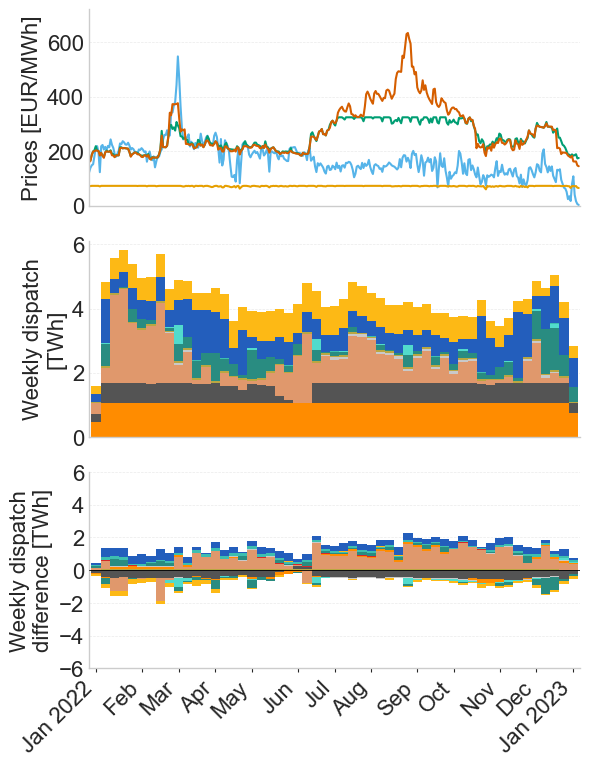

In [94]:
import matplotlib as mpl
# ── Figure ─────────────────────────────────────────────────────────────────────
phi = 1.618
fig, axs = plt.subplots(
    ncols=1,
    nrows=3,
    figsize=(x_length, x_length * phi * 0.8),
    sharex=False,
)

# ── Global style (mirrors setup_style) ────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams["axes.spines.right"]   = False
mpl.rcParams["axes.spines.top"]     = False
plt.rcParams["font.family"]         = "Arial"
plt.rcParams["axes.titleweight"]    = "bold"
plt.rcParams["axes.labelsize"]      = 16
plt.rcParams["xtick.labelsize"]     = 16
plt.rcParams["ytick.labelsize"]     = 16
plt.rcParams["legend.fontsize"]     = 16
plt.rcParams["legend.title_fontsize"] = 16

# ── ax[0] : Prices ─────────────────────────────────────────────────────────────
plot_order = [
    "benchmark",
    "hindcast-std",
    "hindcast-dyn",
    "hindcast-dyn-rolling",
]

sim_color = {
    "benchmark":            "#56b4e9",
    "hindcast-dyn":         "#009e73",
    "hindcast-dyn-rolling": "#d55e00",
    "hindcast-std":         "#e69f00",
}

for label in plot_order:
    if label not in prices_dict:
        continue
    df = prices_dict[label]
    if country not in df.columns:
        continue
    series = df[country]
    if resampling_rule:
        series = series.resample("D").mean()
    axs[0].plot(series, label=label, color=sim_color.get(label, None))

axs[0].set_xlim(left=start_date, right=end_date)
axs[0].set_ylim(bottom=0, top=720)
axs[0].set_ylabel("Prices [EUR/MWh]")
axs[0].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[0].xaxis.grid(False)
axs[0].set_axisbelow(True)
axs[0].set_xticks([])
axs[0].tick_params(axis="y", which="both", left=False)

# ── ax[1] : Dispatch ───────────────────────────────────────────────────────────
carrier_order = [
    "Lignite",
    "Nuclear",
    "Coal",
    "Gas",
    "Oil",
    "Biomass",
    "Reservoir & Dam",
    "Pumped Hydro Storage",
    "Run-of-river",
    "Wind Offshore",
    "Wind Onshore",
    "Solar",
]

def reorder_columns(df, order):
    existing  = [c for c in order if c in df.columns]
    remaining = [c for c in df.columns if c not in existing]
    return df[existing + remaining]

country_dispatch_res_twh = reorder_columns(country_dispatch_res, carrier_order) / 1000
country_dispatch_res_twh.plot.bar(
    stacked=True, width=1.0, ax=axs[1], legend=False,
    color=color_dict_new,
)
axs[1].set_ylabel("Weekly dispatch\n[TWh]")
axs[1].set_xlabel("")
axs[1].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[1].xaxis.grid(False)
axs[1].set_axisbelow(True)
axs[1].set_xticks([])
axs[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
axs[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
axs[1].tick_params(axis="y", which="both", left=False)

# ── ax[2] : Dispatch difference ────────────────────────────────────────────────
diff_res_plot = diff_res.copy() / 1000
diff_timestamps = diff_res_plot.index
diff_res_plot = diff_res_plot.reset_index(drop=True)

diff_res_plot.plot.bar(
    stacked=True, width=1.0, ax=axs[2], legend=False,
    color=color_dict_new,
)
axs[2].set_xlabel("")
axs[2].set_ylabel("Weekly dispatch\ndifference [TWh]")
axs[2].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[2].xaxis.grid(False)
axs[2].set_axisbelow(True)
axs[2].set_ylim(bottom=-6, top=6)
axs[2].yaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
axs[2].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
axs[2].tick_params(axis="y", which="both", left=False)
axs[2].axhline(0, color="black", linewidth=0.6, zorder=3)

# Monthly ticks
tick_positions = []
tick_labels    = []
prev_month     = None
for i, ts in enumerate(diff_timestamps):
    if ts.month != prev_month:
        tick_positions.append(i)
        tick_labels.append(
            ts.strftime("%b %Y") if (ts.month == 1 or prev_month is None)
            else ts.strftime("%b")
        )
        prev_month = ts.month
axs[2].set_xticks(tick_positions)
axs[2].set_xticklabels(tick_labels, rotation=45, ha="right")
axs[2].tick_params(axis="x", length=3)

# ── Shared spine cleanup ────────────────────────────────────────────────────────
for ax in axs:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


plt.tight_layout()
# Save the figure
file_path = figure_dir / "price_dispatch_comparison_ES.pdf"
plt.savefig(file_path, bbox_inches="tight")
plt.show()